# IMDB reviews - Text Analysis

## Understanding data

Load functions

In [2]:
from sklearn.datasets import load_files
import tarfile
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

Load dataset

In [3]:
# tar = tarfile.open("data/aclImdb_v1.tar.gz", "r:gz")
# tar.extractall("data/")
# tar.close()

In [4]:
reviews_train = load_files("data/aclImdb/train/", categories=['pos', 'neg'])
text_train, y_train = reviews_train.data, reviews_train.target
print("type of text_train: {}".format(type(text_train)))
print("length of text_train: {}".format(len(text_train)))
print("text_train[1]:\n{}".format(text_train[1]))

type of text_train: <class 'list'>
length of text_train: 25000
text_train[1]:
b'Words can\'t describe how bad this movie is. I can\'t explain it by writing only. You have too see it for yourself to get at grip of how horrible a movie really can be. Not that I recommend you to do that. There are so many clich\xc3\xa9s, mistakes (and all other negative things you can imagine) here that will just make you cry. To start with the technical first, there are a LOT of mistakes regarding the airplane. I won\'t list them here, but just mention the coloring of the plane. They didn\'t even manage to show an airliner in the colors of a fictional airline, but instead used a 747 painted in the original Boeing livery. Very bad. The plot is stupid and has been done many times before, only much, much better. There are so many ridiculous moments here that i lost count of it really early. Also, I was on the bad guys\' side all the time in the movie, because the good guys were so stupid. "Executive Decisio

load_files returns a dictionary with data, target_names, target as the keys.

Cleaning html breaks (\<br />)

In [5]:
text_train = [doc.replace(b"<br />", b" ") for doc in text_train]

Check balance of classes

In [6]:
print("Samples per class (training): {}".format(np.bincount(y_train)))

Samples per class (training): [12500 12500]


Load test data

In [7]:
reviews_test = load_files("data/aclImdb/test", categories=['pos', 'neg'])
text_test, y_test = reviews_test.data, reviews_test.target
print("Number of documents in test data: {}".format(len(text_test)))
print("Samples per class(test): {}".format(np.bincount(y_test)))
text_test = [doc.replace(b"<br />", b" ") for doc in text_test]

Number of documents in test data: 25000
Samples per class(test): [12500 12500]


## Representing text data as Bag of Words

### example mock dataset

In [8]:
bards_words =["The fool doth think he is wise,",
 "but the wise man knows himself to be a fool"]

In [9]:
vect = CountVectorizer()
vect.fit(bards_words)

CountVectorizer()

this consists of tokenization of the training data and building of the vocabulary

In [10]:
print("Vocabulary size: {}".format(len(vect.vocabulary_)))

Vocabulary size: 13


In [11]:
print("Vocabulary content: {}".format(vect.vocabulary_))

Vocabulary content: {'the': 9, 'fool': 3, 'doth': 2, 'think': 10, 'he': 4, 'is': 6, 'wise': 12, 'but': 1, 'man': 8, 'knows': 7, 'himself': 5, 'to': 11, 'be': 0}


BoW representation

In [12]:
bag_of_words = vect.transform(bards_words)
print("bag_of_words: {}".format(repr(bag_of_words)))

bag_of_words: <Compressed Sparse Row sparse matrix of dtype 'int64'
	with 16 stored elements and shape (2, 13)>


view the sparse bag_of_words matrix

In [13]:
print("Dense representation:\n{}".format(bag_of_words.toarray()))

Dense representation:
[[0 0 1 1 1 0 1 0 0 1 1 0 1]
 [1 1 0 1 0 1 0 1 1 1 0 1 1]]


## Bag-of-Words for Movie Reviews

In [14]:
vect = CountVectorizer().fit(text_train)
X_train = vect.transform(text_train)
print("X_train:\n{}".format(repr(X_train)))

X_train:
<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 3431196 stored elements and shape (25000, 74849)>


look at the features in detail

In [15]:
feature_names = vect.get_feature_names_out()
print("Number of features: {}".format(len(feature_names)))
print("First 25 features:\n{}".format(feature_names[:25]))
print("Features 20010 to 20030:\n{}".format(feature_names[20010:20030]))
print("Every 3000th feature:\n{}".format(feature_names[::3000]))

Number of features: 74849
First 25 features:
['00' '000' '0000000000001' '00001' '00015' '000s' '001' '003830' '006'
 '007' '0079' '0080' '0083' '0093638' '00am' '00pm' '00s' '01' '01pm' '02'
 '020410' '029' '03' '04' '041']
Features 20010 to 20030:
['dratted' 'draub' 'draught' 'draughts' 'draughtswoman' 'draw' 'drawback'
 'drawbacks' 'drawer' 'drawers' 'drawing' 'drawings' 'drawl' 'drawled'
 'drawling' 'drawn' 'draws' 'draza' 'dre' 'drea']
Every 3000th feature:
['00' 'ameliorated' 'barking' 'breslin' 'chicanery' 'cost' 'detox'
 'eeriest' 'favorit' 'gazongas' 'hasan' 'imtiaz' 'kantrowitz'
 'listlessness' 'megalunged' 'nathaniel' 'padilla' 'possessed'
 'receptionist' 'sabres' 'shunning' 'steakley' 'temptations' 'umney'
 'walkman']


get any 5 reviews with word '007'

In [16]:
indices = np.where(X_train[:,vect.vocabulary_.get('007', -1)].toarray()>0)[0]
# Print the first 5 reviews with '007'
for i in indices[:5]:
  print(f"Review {i+1}: {text_train[i]}")

Review 555: b'"Dutch Schultz", AKA Arthur Fleggenheimer, was a real person and his rather nasty life is fairly well documented. This movie which purports to depict his life should have used a fictional character, because the overdramatized events are too strong a departure from the facts and the chronology. Not only that, it ignores some interesting details which other versions have included such as the public relations fiasco in upstate N.Y. and his religious conversion. It is true that he was executed by Luciano, Lansky, et. al. but that\'s as far as it goes. The exploding plate scene which represents Luciano carrying out the execution of Bo Weinberg in his own home, assisted by his own mother is rediculous. Also, there is the scene in which Dutch approaches his own mother to pay protection to Legs Diamond. It just doesn\'t work. The character of Mrs. Fleggenheimer doesn\'t work either. This movie does not need a doting Jewish mother for comic relief. The lame representation of Legs 

## Baseline classifier


In [17]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

In [18]:
scores = cross_val_score(LogisticRegression(max_iter=2000), X_train, y_train, cv=5)

In [19]:
print(f"Mean cross-validation accuracy: {np.mean(scores):.2f}")

Mean cross-validation accuracy: 0.88


Hyperparameter tuning

In [20]:
param = {'C' : [.001, .01, .1, 1, 10]}
grid = GridSearchCV(LogisticRegression(max_iter=500), param, cv=5, n_jobs=-1)
grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=500), n_jobs=-1,
             param_grid={'C': [0.001, 0.01, 0.1, 1, 10]})

In [21]:
print(f"Best cross-validation score: {grid.best_score_:.2f}")
print(f"Best parameters: {grid.best_params_}")

Best cross-validation score: 0.89
Best parameters: {'C': 0.1}


Assessing the performance on the test set

In [22]:
X_test = vect.transform(text_test)
print(f"Test score: {grid.score(X_test, y_test):.2f}")

Test score: 0.88


## Improve word extraction

set min documents a word should appear in to be included in vocabulary

In [23]:
vect = CountVectorizer(min_df=5).fit(text_train)
X_train = vect.transform(text_train)
print("X_train with min_df:{}".format(repr(X_train)))

X_train with min_df:<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 3354014 stored elements and shape (25000, 27271)>


In [24]:
feature_names = vect.get_feature_names_out()
print("Number of features: {}".format(len(feature_names)))
print("First 50 features:\n{}".format(feature_names[:50]))
print("Features 20010 to 20030:\n{}".format(feature_names[20010:20030]))
print("Every 700th feature:\n{}".format(feature_names[::700]))

Number of features: 27271
First 50 features:
['00' '000' '007' '00s' '01' '02' '03' '04' '05' '06' '07' '08' '09' '10'
 '100' '1000' '100th' '101' '102' '103' '104' '105' '107' '108' '10s'
 '10th' '11' '110' '112' '116' '117' '11th' '12' '120' '12th' '13' '135'
 '13th' '14' '140' '14th' '15' '150' '15th' '16' '160' '1600' '16mm' '16s'
 '16th']
Features 20010 to 20030:
['repentance' 'repercussions' 'repertoire' 'repetition' 'repetitions'
 'repetitious' 'repetitive' 'rephrase' 'replace' 'replaced' 'replacement'
 'replaces' 'replacing' 'replay' 'replayable' 'replayed' 'replaying'
 'replays' 'replete' 'replica']
Every 700th feature:
['00' 'affections' 'appropriately' 'barbra' 'blurbs' 'butchered' 'cheese'
 'commitment' 'courts' 'deconstructed' 'disgraceful' 'dvds' 'eschews'
 'fell' 'freezer' 'goriest' 'hauser' 'hungary' 'insinuate' 'juggle'
 'leering' 'maelstrom' 'messiah' 'music' 'occasional' 'parking'
 'pleasantville' 'pronunciation' 'recipient' 'reviews' 'sas' 'shea'
 'sneers' 'steiger'

checking model performance

In [25]:
grid = GridSearchCV(LogisticRegression(max_iter=500), param, cv=5, n_jobs=-1)
grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=500), n_jobs=-1,
             param_grid={'C': [0.001, 0.01, 0.1, 1, 10]})

In [26]:
print(f"Best cross-validation score: {grid.best_score_:.2f}")
print(f"Best parameters: {grid.best_params_}")

Best cross-validation score: 0.89
Best parameters: {'C': 0.1}


## Stop Words

In [27]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

In [28]:
print(f"No. of stop words: {len(ENGLISH_STOP_WORDS)}")
print(f"Every 10th stopword: {list(ENGLISH_STOP_WORDS)[::10]}")

No. of stop words: 318
Every 10th stopword: ['two', 'nothing', 'herself', 'afterwards', 'per', 'he', 'until', 'us', 'within', 'front', 'could', 're', 'elsewhere', 'these', 'might', 'they', 'her', 'now', 'from', 'under', 'though', 'were', 'eg', 'it', 'same', 'whom', 'made', 'eight', 'by', 'how', 'throughout', 'in']


In [29]:
vect = CountVectorizer(min_df=5, stop_words='english').fit(text_train)
X_train = vect.transform(text_train)
print(f"X_train with stop words: {repr(X_train)}")

X_train with stop words: <Compressed Sparse Row sparse matrix of dtype 'int64'
	with 2149958 stored elements and shape (25000, 26966)>


In [30]:
grid = GridSearchCV(LogisticRegression(max_iter=400), param, cv=5)
grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=400),
             param_grid={'C': [0.001, 0.01, 0.1, 1, 10]})

In [31]:
print(f"Best cross-validation score: {grid.best_score_:.2f}")

Best cross-validation score: 0.88


## Experimenting with max_df

baseline with just min_df=5

X_train with max_df: <Compressed Sparse Row sparse matrix of dtype 'int64' with 3354014 stored elements and shape (25000, 27271)>

In [32]:
max_df = 1000
vect = CountVectorizer(min_df=5, max_df=max_df).fit(text_train)
X_train = vect.transform(text_train)
print(f"X_train with max_df {max_df}: {repr(X_train)}")

X_train with max_df 1000: <Compressed Sparse Row sparse matrix of dtype 'int64'
	with 1441223 stored elements and shape (25000, 26749)>


X_train with max_df 20000: <Compressed Sparse Row sparse matrix of dtype 'int64' with 3148142 stored elements and shape (25000, 27262)>

In [33]:
grid = GridSearchCV(LogisticRegression(), param, cv=5, n_jobs=-1)
grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(), n_jobs=-1,
             param_grid={'C': [0.001, 0.01, 0.1, 1, 10]})

In [34]:
print(f"Best cross-validation score: {grid.best_score_:.2f}")

Best cross-validation score: 0.85


The model is giving an accuracy score of 0.85 which is not significantly lower than the earlier model's score of 0.89, and also the count of features has gone down from 27271 to 26749.

In [35]:
27271-26749

522

## Rescaling the data with tf-idf

creating pipeline


In [36]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import make_pipeline

In [37]:
pipe = make_pipeline(TfidfVectorizer(min_df=5, norm=None),
                     LogisticRegression(max_iter=200))
param = {'logisticregression__C': [.001, .01, .1, 1, 10]}
grid = GridSearchCV(pipe, param, cv=5, n_jobs=2)
grid.fit(text_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('tfidfvectorizer',
                                        TfidfVectorizer(min_df=5, norm=None)),
                                       ('logisticregression',
                                        LogisticRegression(max_iter=200))]),
             n_jobs=2,
             param_grid={'logisticregression__C': [0.001, 0.01, 0.1, 1, 10]})

In [38]:
print(f"Best cross-validation score: {grid.best_score_:.2f}")

Best cross-validation score: 0.89


In [39]:
vectorizer = grid.best_estimator_.named_steps["tfidfvectorizer"]
X_train = vectorizer.transform(text_train)
max_value = X_train.max(axis=0).toarray().ravel()
sorted_by_tfidf = max_value.argsort()
feature_names = np.array(vectorizer.get_feature_names_out())
print(f"Features with lowest tfidf:\n{feature_names[sorted_by_tfidf[:20]]}")
print(f"Features with highest tfidf:\n{feature_names[sorted_by_tfidf[-20:]]}")

Features with lowest tfidf:
['poignant' 'disagree' 'instantly' 'importantly' 'lacked' 'occurred'
 'currently' 'altogether' 'nearby' 'undoubtedly' 'directs' 'fond'
 'stinker' 'avoided' 'emphasis' 'commented' 'realizing' 'disappoint'
 'downhill' 'inane']
Features with highest tfidf:
['coop' 'homer' 'dillinger' 'hackenstein' 'gadget' 'taker' 'macarthur'
 'vargas' 'jesse' 'basket' 'dominick' 'the' 'victor' 'bridget' 'victoria'
 'khouri' 'zizek' 'rob' 'timon' 'titanic']


words that have low idf

In [40]:
sorted_by_idf = np.argsort(vectorizer.idf_)
print(f"Features with lowest idf:\n{feature_names[sorted_by_idf[:100]]}")

Features with lowest idf:
['the' 'and' 'of' 'to' 'this' 'is' 'it' 'in' 'that' 'but' 'for' 'with'
 'was' 'as' 'on' 'movie' 'not' 'have' 'one' 'be' 'film' 'are' 'you' 'all'
 'at' 'an' 'so' 'by' 'from' 'like' 'who' 'they' 'there' 'if' 'his' 'out'
 'just' 'about' 'he' 'or' 'has' 'what' 'some' 'good' 'can' 'more' 'when'
 'time' 'up' 'very' 'even' 'only' 'no' 'would' 'my' 'see' 'really' 'story'
 'which' 'well' 'had' 'me' 'than' 'much' 'their' 'get' 'were' 'other'
 'been' 'do' 'most' 'don' 'her' 'also' 'into' 'first' 'made' 'how' 'great'
 'because' 'will' 'people' 'make' 'way' 'could' 'we' 'bad' 'after' 'any'
 'too' 'then' 'them' 'she' 'watch' 'think' 'acting' 'movies' 'seen' 'its'
 'him']


## Investigating Model Coefficients

In [41]:
logitreg = grid.best_estimator_.named_steps['logisticregression']
coeff = logitreg.coef_[0]
sorted_coeff_index = np.argsort(coeff)
smallest_coeff = sorted_coeff_index[:25]
largest_coeff = sorted_coeff_index[-25:]
coeff_to_plot = np.concatenate((smallest_coeff, largest_coeff))
coeff_to_plot_names = np.concatenate((feature_names[smallest_coeff], feature_names[largest_coeff]))
coeff_to_plot_values = np.concatenate((coeff[smallest_coeff], coeff[largest_coeff]))

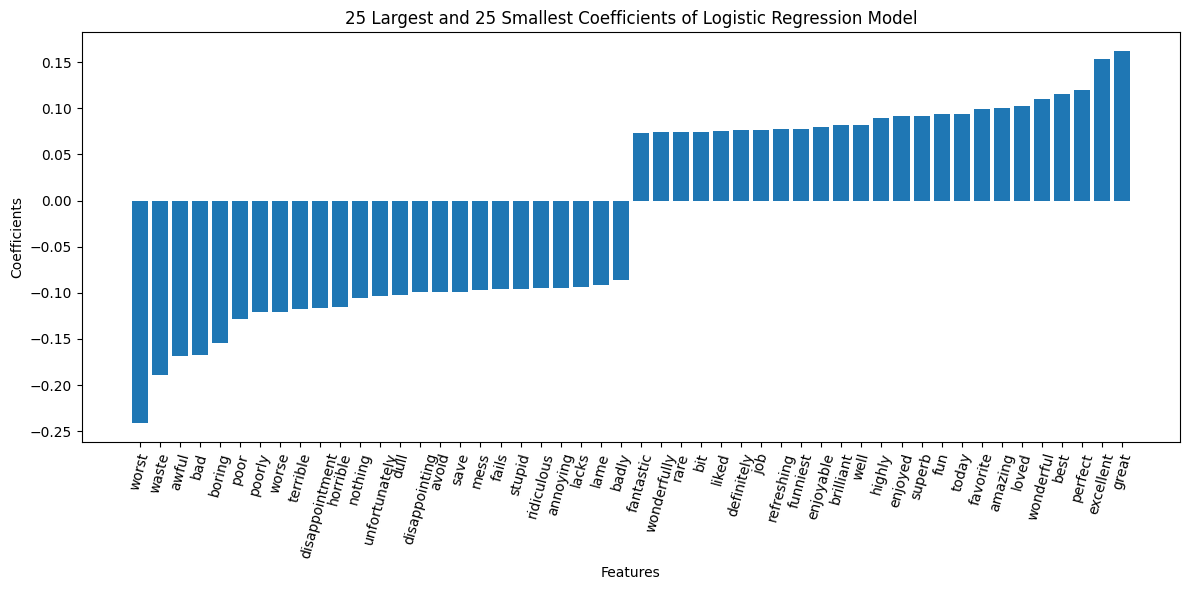

In [42]:
plt.figure(figsize=(12,6))
plt.bar(range(len(coeff_to_plot)), coeff_to_plot_values, align='center')
plt.xticks(range(len(coeff_to_plot)), coeff_to_plot_names, rotation=75)
plt.title('25 Largest and 25 Smallest Coefficients of Logistic Regression Model')
plt.xlabel('Features')
plt.ylabel('Coefficients')
plt.tight_layout()
plt.show()

## using more than a word (n-grams)

In [43]:
import tempfile

with tempfile.TemporaryDirectory() as temp_dir:
    pipe = make_pipeline(
        TfidfVectorizer(min_df=5),
        LogisticRegression(solver='saga'),
        memory=temp_dir)
    param = {'logisticregression__C': [0.1, 1, 10, 100],
         'tfidfvectorizer__ngram_range': [(1,1), (1,2), (1,3)]}
    grid = GridSearchCV(pipe, param, cv=5, verbose=True)
    grid.fit(text_train, y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


c:\Users\akuka\OneDrive\Documents\Projects\imdb_reviews_sentiment_analysis\venv-nlp\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\akuka\OneDrive\Documents\Projects\imdb_reviews_sentiment_analysis\venv-nlp\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\akuka\OneDrive\Documents\Projects\imdb_reviews_sentiment_analysis\venv-nlp\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\akuka\OneDrive\Documents\Projects\imdb_reviews_sentiment_analysis\venv-nlp\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\akuka\OneDrive\Documents\Projects\imdb_revi

In [44]:
print(f"Best cross-validation score: {grid.best_score_:.2f}")
print(f"Best parameters:\n{grid.best_params_}")

Best cross-validation score: 0.91
Best parameters:
{'logisticregression__C': 100, 'tfidfvectorizer__ngram_range': (1, 3)}


In [45]:
result = pd.DataFrame(grid.cv_results_)
result.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_logisticregression__C,param_tfidfvectorizer__ngram_range,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,4.086348,0.147828,0.762136,0.092698,0.1,"(1, 1)","{'logisticregression__C': 0.1, 'tfidfvectorize...",0.8496,0.8466,0.8536,0.8492,0.8508,0.84996,0.002278,11
1,10.941622,0.118308,1.649355,0.048517,0.1,"(1, 2)","{'logisticregression__C': 0.1, 'tfidfvectorize...",0.8518,0.8428,0.8564,0.8530,0.8480,0.85040,0.004653,10
2,21.392942,2.133907,2.981732,0.502126,0.1,"(1, 3)","{'logisticregression__C': 0.1, 'tfidfvectorize...",0.8482,0.8432,0.8542,0.8518,0.8496,0.84940,0.003707,12
3,1.398525,0.115960,1.046193,0.099672,1.0,"(1, 1)","{'logisticregression__C': 1, 'tfidfvectorizer_...",0.8850,0.8852,0.8924,0.8922,0.8850,0.88796,0.003545,8
4,2.664885,0.143322,2.209404,0.060704,1.0,"(1, 2)","{'logisticregression__C': 1, 'tfidfvectorizer_...",0.8948,0.8862,0.8968,0.8950,0.8922,0.89300,0.003703,5


In [46]:
scores = grid.cv_results_['mean_test_score'].reshape(-1,3)
scores

array([[0.84996, 0.8504 , 0.8494 ],
       [0.88796, 0.893  , 0.89244],
       [0.89188, 0.90508, 0.90636],
       [0.88292, 0.90616, 0.9064 ]])

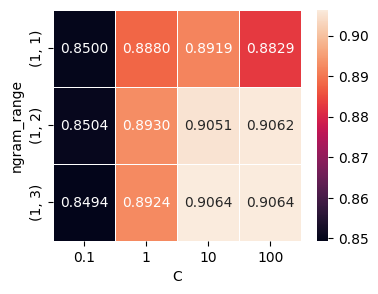

In [47]:
import seaborn as sns
scores = grid.cv_results_['mean_test_score'].reshape(-1,3).T
fig, ax = plt.subplots(figsize=(4,3))
ax = sns.heatmap(scores,
                      xticklabels=param['logisticregression__C'],
                      yticklabels=param['tfidfvectorizer__ngram_range'],
                      fmt='.4f', annot=True, linewidth=.5)
ax.set_xlabel('C')
ax.set_ylabel('ngram_range')
plt.show()

In [48]:
vect = grid.best_estimator_.named_steps['tfidfvectorizer']
feature_names = np.array(vect.get_feature_names_out())
coef = grid.best_estimator_.named_steps['logisticregression'].coef_[0]
coef_sorted_idx = np.argsort(coef)
n_features = 40
coef_sorted_idx_top = coef_sorted_idx[-n_features:]
coef_sorted_idx_low = coef_sorted_idx[:n_features]

Text(0, 0.5, 'Coefficient Magnitude')

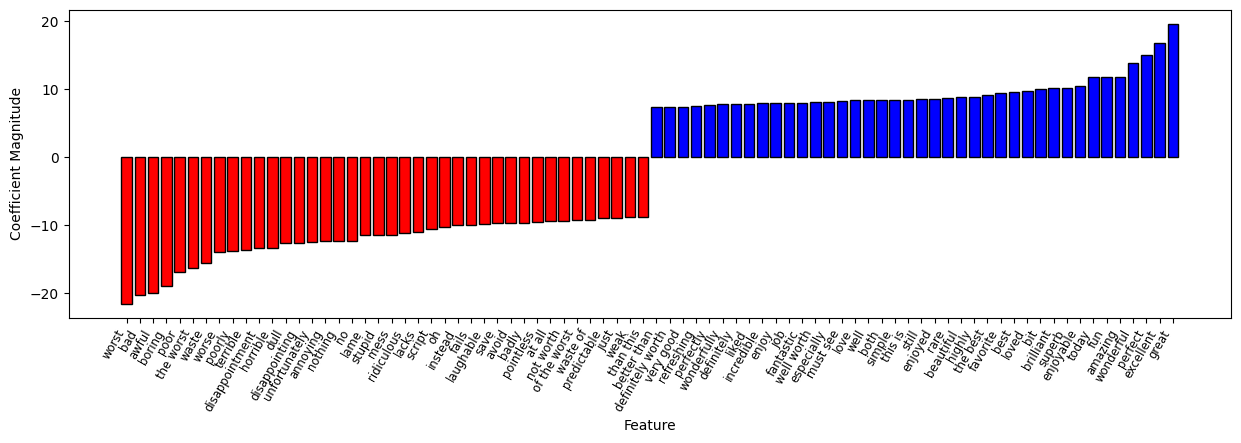

In [49]:
fig = plt.figure(figsize=(15,4))

plt.bar(range(-n_features,0), coef[coef_sorted_idx_low], color='r', edgecolor='k')
plt.bar(range(0, n_features), coef[coef_sorted_idx_top], color='b', edgecolor='k')
plt.xticks(range(-n_features, n_features), feature_names[np.hstack([coef_sorted_idx_low, coef_sorted_idx_top])], rotation=60, ha='right', size='small')
plt.xlabel('Feature')
plt.ylabel('Coefficient Magnitude')

## Advanced Tokenisation

In [50]:
import spacy
import nltk

In [52]:
en_nlp = spacy.load('en_core_web_sm')
stemmer = nltk.stem.PorterStemmer()

In [53]:
def compare_normalization(doc):
  doc_spacy = en_nlp(doc)
  print("Lemmatization:")
  print([token.lemma_ for token in doc_spacy])

  print('Stemming:')
  print([stemmer.stem(token.norm_.lower()) for token in doc_spacy])


In [54]:
compare_normalization(u"Our meeting today was worse than yesterday, "
 "I'm scared of meeting the clients tomorrow.")

Lemmatization:
['our', 'meeting', 'today', 'be', 'bad', 'than', 'yesterday', ',', 'I', 'be', 'scared', 'of', 'meet', 'the', 'client', 'tomorrow', '.']
Stemming:
['our', 'meet', 'today', 'wa', 'wors', 'than', 'yesterday', ',', 'i', 'am', 'scare', 'of', 'meet', 'the', 'client', 'tomorrow', '.']


## lemmatization with scikit-learn

In [55]:
import re
from tqdm import tqdm

regexp = re.compile('(?u)\\b\\w\\w+\\b')
en_nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])

def fast_lemmatizer(documents, batch_size=2000, show_progress=True):
  documents = [doc.decode("utf-8") if isinstance(doc, bytes) else doc for doc in documents]
  tokenized_docs = [" ".join(regexp.findall(doc)) for doc in documents]

  pipe = en_nlp.pipe(tokenized_docs, batch_size=batch_size)
  if show_progress:
    pipe = tqdm(pipe, total=len(documents), desc='Lemmatizing')

  lemmatized_docs = [
      " ".join(token.lemma_ for token in doc if not token.is_punct and not token.is_space)
      for doc in pipe
  ]
  return lemmatized_docs

vectorizer = CountVectorizer(min_df=5)

transform text_train using CountVectorizer with lemmatization

In [56]:
lemmatized_doc = fast_lemmatizer(text_train)

Lemmatizing: 100%|██████████| 25000/25000 [07:37<00:00, 54.66it/s]  


In [57]:
X_train_lemma = vectorizer.fit_transform(lemmatized_doc)
print(f"X_train_lemma.shape: {X_train_lemma.shape}")

X_train_lemma.shape: (25000, 21983)


In [58]:
X_train = vectorizer.fit_transform(text_train)
print(f"X_train.shape: {X_train.shape}")

X_train.shape: (25000, 27271)


## Training on only 1% of the data

In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit

param_grid = {'C' : [.001, .01, .1, 1, 10]}
cv = StratifiedShuffleSplit(n_splits=5, test_size=0.99, random_state=0)

grid = GridSearchCV(LogisticRegression(max_iter=1000), param_grid, cv=cv, n_jobs=2)
grid.fit(X_train_lemma, y_train)
print(f"Best cross-validation score\nLemmatization: {grid.best_score_:.3f}")

grid.fit(X_train, y_train)
print(f"\nBest cross-validation score\nStandard CountVectorizer: {grid.best_score_:.3f}")

Best cross-validation score
Lemmatization: 0.728
Best cross-validation score
Standard CountVectorizer: 0.719


# Topic Modeling and Document Clustering

## Latent Dirichlet Allocation (LDA)

remove words that appear in at
 least 20 percent of the documents, and we’ll limit the bag-of-words model to the
 10,000 words that are most common after removing the top 20 percent

In [61]:
vect = CountVectorizer(max_features=10000, max_df=.2)
X = vect.fit_transform(text_train)

In [62]:
X.shape

(25000, 10000)

In [63]:
from sklearn.decomposition import LatentDirichletAllocation
lda = LatentDirichletAllocation(n_components=10, learning_method="batch", max_iter=25, random_state=0)
document_topics = lda.fit_transform(X)

In [64]:
lda.components_.shape

(10, 10000)

to understand topics, look at the most important words for each of the topics

In [65]:
sorting = np.argsort(lda.components_, axis=1)[:,::-1]
feature_names = np.array(vect.get_feature_names_out())

sorting

array([[4401, 3506, 7770, ..., 3178, 5465, 9524],
       [ 233,  498, 2692, ..., 9524, 1275,  651],
       [5510, 6233, 9776, ..., 7969, 4165, 9608],
       ...,
       [5261, 5407, 3376, ..., 6079, 8755, 1526],
       [5963, 5964, 8304, ...,  760, 4989,  651],
       [6559,  986, 7576, ..., 1437, 9967,  973]], shape=(10, 10000))

In [ ]:
for i in range(len(lda.components_)):
  print(f"Topic {i}")
  print(feature_names[sorting[i, :10]])

model with 100 topics

In [ ]:
lda100 = LatentDirichletAllocation(n_components=100, learning_method="online", max_iter=25, random_state=0)
document_topics100 = lda100.fit_transform(X)

In [ ]:
sorting = np.argsort(lda100.components_, axis=1)[:, ::-1]
for i in range(10):
  print(f"Topic {i}")
  print(feature_names[sorting[i, :20]])

Topic 6 - war movies

In [ ]:
document_topics100.shape

In [ ]:
war = np.argsort(document_topics100[:,6])[::-1]
for i in war[:10]:
  #first two sentences
  print( b".".join(text_train[i].split(b".")[:2]) + b".\n")

inspect the topics is to see how much weight each topic gets over
all, by summing the document_topics over all reviews.

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(10,10))
topic_names = [
    f"{i:>2} " + " ".join(words)
    for i, words in enumerate(feature_names[sorting[:,:2]])
]

for col in [0,1]:
  start = col*50
  end = (col+1)*50
  ax[col].barh(np.arange(50), np.sum(document_topics100, axis=0)[start:end])
  ax[col].set_yticks(np.arange(50))
  ax[col].set_yticklabels(topic_names[start:end], ha='left', va='top')
  ax[col].invert_yaxis()
  ax[col].set_xlim(0,1500)
  yax = ax[col].get_yaxis()
  yax.set_tick_params(pad=120)
plt.tight_layout()
plt.show()